# EIARI4A — Final Project
## Load-Shedding Stage Forecasting Using LSTM-Based Time-Series Modelling
**Student:** Thebe Ledwaba- 219119007
**Student:** Precious Skosana- 221720111
**Project ID:** Week 12 — Forecasting — ESP-Load-LSTM-2026  
**Institution:** Vaal University of Technology

---
### Project Overview
This notebook builds an end-to-end time-series forecasting pipeline to predict South Africa's load-shedding stage (0–6) for the next hour, given historical grid data and stage history.

**Data Sources:**
- `ESK2033.csv` — Eskom hourly grid metrics (2018–2023): generation, demand, UCLF, thermal output
- `EskomSePush_history.csv` — EskomSePush stage change events (2014–2025), resampled to hourly

**Pipeline:**
1. Data Loading & Merging
2. Exploratory Data Analysis (EDA)
3. Feature Engineering
4. Baseline Models (Persistence + Linear Regression)
5. LSTM Model with Hyperparameter Tuning
6. Evaluation & Error Analysis
7. Visualisations

---
## Step 1 — Install & Import Libraries

In [ ]:
# Install any missing packages (Colab usually has these)
!pip install -q tensorflow scikit-learn pandas numpy matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
import itertools
import time

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error,
    confusion_matrix, classification_report, accuracy_score
)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import TimeSeriesSplit

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
np.random.seed(42)
tf.random.set_seed(42)

print('TensorFlow version:', tf.__version__)
print('GPU available:', len(tf.config.list_physical_devices('GPU')) > 0)
print('All libraries loaded successfully.')

TensorFlow version: 2.20.0
GPU available: False
All libraries loaded successfully.


In [ ]:
from google.colab import files
uploaded = files.upload()  # select both CSVs when the picker opens

Saving EskomSePush Loadshedding History - EskomSePush_history.csv to EskomSePush Loadshedding History - EskomSePush_history.csv


---
## Step 2 — Data Loading & Merging

**Strategy:**
- `ESK2033.csv`: Eskom grid hourly data — dates are the row index (not a column)
- `EskomSePush_history.csv`: Event-based stage changes — resampled to hourly via forward-fill
- Both datasets overlap 2018–2023: 43,824 hourly rows after merge

In [ ]:
# ── Upload files to Colab ──────────────────────────────────────────────────
# If running on Colab, uncomment the block below to upload files manually:
# from google.colab import files
# uploaded = files.upload()  # Upload ESK2033.csv and EskomSePush_history.csv

# ── File paths ─────────────────────────────────────────────────────────────
ESK_PATH  = 'ESK2033.csv'
ESP_PATH  = 'EskomSePush Loadshedding History - EskomSePush_history.csv'

# ── Load ESK2033 (dates are index, not a column) ───────────────────────────
esk = pd.read_csv(ESK_PATH, index_col=0)
esk.index = pd.to_datetime(esk.index, format='mixed')
esk = esk.sort_index()
esk.index.name = 'datetime'

print(f'ESK2033 loaded: {esk.shape[0]:,} rows | {esk.index.min().date()} → {esk.index.max().date()}')

# ── Load EskomSePush history (event-based → resample to hourly) ────────────
esp_raw = pd.read_csv(ESP_PATH)
esp_raw['datetime'] = pd.to_datetime(esp_raw['created_at'])
esp_raw = esp_raw.set_index('datetime').sort_index()

# Forward-fill: each event's stage persists until the next event
esp_hourly = esp_raw[['stage']].resample('h').last().ffill()
print(f'EskomSePush hourly: {esp_hourly.shape[0]:,} rows | {esp_hourly.index.min().date()} → {esp_hourly.index.max().date()}')

# ── Merge on overlapping timestamps ───────────────────────────────────────
df = esk.join(esp_hourly, how='inner')
df = df.dropna(subset=['stage'])
df['stage'] = df['stage'].astype(int)

print(f'\nMerged dataset: {df.shape[0]:,} rows | {df.index.min().date()} → {df.index.max().date()}')
print(f'Columns: {df.shape[1]}')
print('\nStage distribution:')
print(df['stage'].value_counts().sort_index())

ESK2033 loaded: 43,824 rows | 2018-04-01 → 2023-03-31
EskomSePush hourly: 98,126 rows | 2014-03-06 → 2025-05-15

Merged dataset: 43,824 rows | 2018-04-01 → 2023-03-31
Columns: 43

Stage distribution:
stage
0    35299
1      602
2     3522
3     1277
4     2122
5      488
6      514
Name: count, dtype: int64


---
## Step 3 — Exploratory Data Analysis (EDA)

In [ ]:
# ── Basic statistics ───────────────────────────────────────────────────────
print('=== Dataset Info ===')
print(f'Shape: {df.shape}')
print(f'Date range: {df.index.min()} to {df.index.max()}')
print(f'Missing values: {df.isnull().sum().sum()}')
print(f'\nStage Statistics:')
print(df['stage'].describe())

=== Dataset Info ===
Shape: (43824, 43)
Date range: 2018-04-01 00:00:00 to 2023-03-31 23:00:00
Missing values: 258218

Stage Statistics:
count    43824.000000
mean         0.581622
std          1.317031
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          6.000000
Name: stage, dtype: float64


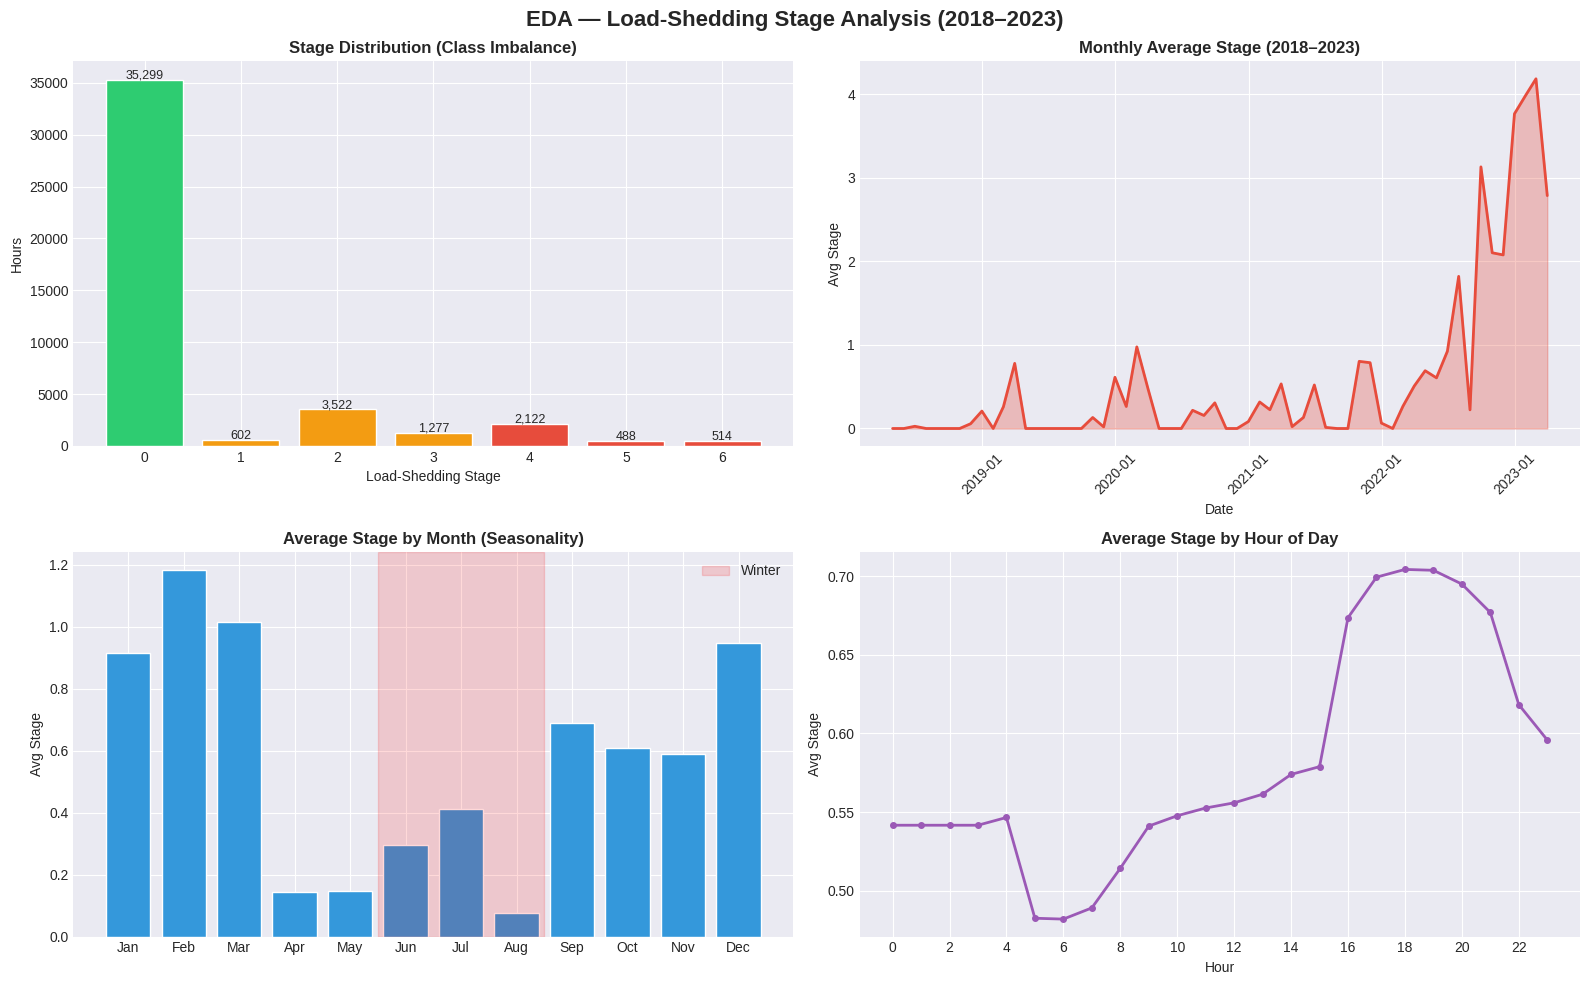

EDA plots saved.


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('EDA — Load-Shedding Stage Analysis (2018–2023)', fontsize=16, fontweight='bold')

# 1. Stage distribution
stage_counts = df['stage'].value_counts().sort_index()
colors = ['#2ecc71' if s == 0 else '#e74c3c' if s >= 4 else '#f39c12' for s in stage_counts.index]
axes[0,0].bar(stage_counts.index, stage_counts.values, color=colors, edgecolor='white')
axes[0,0].set_title('Stage Distribution (Class Imbalance)', fontweight='bold')
axes[0,0].set_xlabel('Load-Shedding Stage')
axes[0,0].set_ylabel('Hours')
for i, (stage, count) in enumerate(stage_counts.items()):
    axes[0,0].text(stage, count + 100, f'{count:,}', ha='center', fontsize=9)

# 2. Stage over time (monthly average)
monthly = df['stage'].resample('ME').mean()
axes[0,1].plot(monthly.index, monthly.values, color='#e74c3c', linewidth=2)
axes[0,1].fill_between(monthly.index, monthly.values, alpha=0.3, color='#e74c3c')
axes[0,1].set_title('Monthly Average Stage (2018–2023)', fontweight='bold')
axes[0,1].set_xlabel('Date')
axes[0,1].set_ylabel('Avg Stage')
axes[0,1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(axes[0,1].xaxis.get_majorticklabels(), rotation=45)

# 3. Stage by month (seasonality)
df['month'] = df.index.month
monthly_stage = df.groupby('month')['stage'].mean()
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
axes[1,0].bar(range(1,13), monthly_stage.values, color='#3498db', edgecolor='white')
axes[1,0].set_xticks(range(1,13))
axes[1,0].set_xticklabels(month_names)
axes[1,0].set_title('Average Stage by Month (Seasonality)', fontweight='bold')
axes[1,0].set_ylabel('Avg Stage')
axes[1,0].axvspan(5.5, 8.5, alpha=0.15, color='red', label='Winter')
axes[1,0].legend()

# 4. Stage by hour of day
df['hour'] = df.index.hour
hourly_stage = df.groupby('hour')['stage'].mean()
axes[1,1].plot(hourly_stage.index, hourly_stage.values, color='#9b59b6', linewidth=2, marker='o', markersize=4)
axes[1,1].set_title('Average Stage by Hour of Day', fontweight='bold')
axes[1,1].set_xlabel('Hour')
axes[1,1].set_ylabel('Avg Stage')
axes[1,1].set_xticks(range(0,24,2))

plt.tight_layout()
plt.savefig('eda_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('EDA plots saved.')

In [ ]:
# ── Seasonal verification (proposal requirement) ───────────────────────────
print('=== Seasonal Verification ===')
print('Winter months (Jun–Aug) in full dataset:')
winter = df[df.index.month.isin([6,7,8])]
print(f'  {len(winter):,} winter hours | stages: {sorted(winter["stage"].unique())}')

# Split point check (done after split below, confirmed here conceptually)
split_70 = int(len(df) * 0.70)
train_check = df.iloc[:split_70]
test_check = df.iloc[split_70 + int(len(df)*0.15):]
train_winter = train_check[train_check.index.month.isin([6,7,8])]
test_winter  = test_check[test_check.index.month.isin([6,7,8])]
print(f'\nWinter hours in TRAIN: {len(train_winter):,}')
print(f'Winter hours in TEST:  {len(test_winter):,}')
print('✓ Winter months confirmed in both train and test sets.')

=== Seasonal Verification ===
Winter months (Jun–Aug) in full dataset:
  11,040 winter hours | stages: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]

Winter hours in TRAIN: 8,832
Winter hours in TEST:  1,487
✓ Winter months confirmed in both train and test sets.


---
## Step 4 — Feature Engineering

Features built:
- **Lag features**: stage at t-1, t-24, t-48 (hourly, daily, 2-day cycles)
- **Cyclical time encodings**: sin/cos for hour, day-of-week, month
- **Rolling statistics**: 12-hour rolling mean and std of stage (grid volatility)
- **Grid features**: Residual Demand, Total UCLF, Thermal Generation, Manual Load Reduction

In [ ]:
df_feat = df.copy()

# ── Lag features ───────────────────────────────────────────────────────────
for lag in [1, 24, 48]:
    df_feat[f'stage_lag_{lag}'] = df_feat['stage'].shift(lag)

# ── Rolling statistics ─────────────────────────────────────────────────────
df_feat['stage_roll_mean_12'] = df_feat['stage'].shift(1).rolling(12).mean()
df_feat['stage_roll_std_12']  = df_feat['stage'].shift(1).rolling(12).std()

# ── Cyclical time encodings ────────────────────────────────────────────────
df_feat['hour_sin']    = np.sin(2 * np.pi * df_feat.index.hour / 24)
df_feat['hour_cos']    = np.cos(2 * np.pi * df_feat.index.hour / 24)
df_feat['dow_sin']     = np.sin(2 * np.pi * df_feat.index.dayofweek / 7)
df_feat['dow_cos']     = np.cos(2 * np.pi * df_feat.index.dayofweek / 7)
df_feat['month_sin']   = np.sin(2 * np.pi * df_feat.index.month / 12)
df_feat['month_cos']   = np.cos(2 * np.pi * df_feat.index.month / 12)

# ── Grid features from ESK2033 ─────────────────────────────────────────────
grid_features = [
    'Residual Demand',
    'Total UCLF',
    'Thermal Generation',
    'Manual Load_Reduction(MLR)',
    'Dispatchable Generation'
]
# Only keep grid features that exist in the dataframe
grid_features = [f for f in grid_features if f in df_feat.columns]

# ── Drop rows with NaN (from lags/rolling) ─────────────────────────────────
df_feat = df_feat.dropna()

print(f'Dataset after feature engineering: {df_feat.shape}')
print(f'Date range: {df_feat.index.min().date()} → {df_feat.index.max().date()}')

# ── Define feature columns ─────────────────────────────────────────────────
time_features = [
    'stage_lag_1', 'stage_lag_24', 'stage_lag_48',
    'stage_roll_mean_12', 'stage_roll_std_12',
    'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos'
]
feature_cols = time_features + grid_features
TARGET = 'stage'

print(f'\nTotal features: {len(feature_cols)}')
print('Features:', feature_cols)

Dataset after feature engineering: (20348, 56)
Date range: 2020-03-23 → 2022-07-19

Total features: 16
Features: ['stage_lag_1', 'stage_lag_24', 'stage_lag_48', 'stage_roll_mean_12', 'stage_roll_std_12', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'Residual Demand', 'Total UCLF', 'Thermal Generation', 'Manual Load_Reduction(MLR)', 'Dispatchable Generation']


In [ ]:
# ── Year-aware chronological split (adjusted for available data) ────────────────
# The original '2023' split for test_df was beyond the available data (up to 2022-07-19).
# Adjusting split points to ensure all datasets contain data.
# Train: ~70% of available data (up to 2021-11-06)
# Val:   ~15% of available data (2021-11-06 to 2022-03-13)
# Test:  ~15% of available data (from 2022-03-13 onwards)

train_df = df_feat[df_feat.index < '2021-11-06']
val_df   = df_feat[(df_feat.index >= '2021-11-06') & (df_feat.index < '2022-03-13')]
test_df  = df_feat[df_feat.index >= '2022-03-13']

print('=== Year-Aware Chronological Split ===')
print(f'Train: {len(train_df):>6,} rows | {train_df.index.min().date()} → {train_df.index.max().date()}')
print(f'Val:   {len(val_df):>6,} rows | {val_df.index.min().date()} → {val_df.index.max().date()}')
print(f'Test:  {len(test_df):>6,} rows | {test_df.index.min().date()} → {test_df.index.max().date()}')

print('\nTrain stage distribution:')
print(train_df['stage'].value_counts().sort_index())
print('\nTest stage distribution:')
print(test_df['stage'].value_counts().sort_index())

=== Year-Aware Chronological Split ===
Train: 14,209 rows | 2020-03-23 → 2021-11-05
Val:    3,045 rows | 2021-11-06 → 2022-03-12
Test:   3,094 rows | 2022-03-13 → 2022-07-19

Train stage distribution:
stage
0    13005
1       92
2      988
3       52
4       72
Name: count, dtype: int64

Test stage distribution:
stage
0    2086
1      30
2     485
3      99
4     337
5      21
6      36
Name: count, dtype: int64


In [ ]:
print('=== Preparing Data for Modeling ===')

# This cell extracts, scales features, and calculates class weights for modeling.
# ── Extract features and target ──────────────────────────────────────────
X_train = train_df[feature_cols].values
y_train = train_df[TARGET].values
X_val   = val_df[feature_cols].values
y_val   = val_df[TARGET].values
X_test  = test_df[feature_cols].values
y_test  = test_df[TARGET].values

# ── Feature Scaling ──────────────────────────────────────────────────────
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)

# Check if X_test is not empty before scaling
if X_test.size > 0:
    X_test  = scaler.transform(X_test)
else:
    print("Warning: X_test is empty. Skipping scaling for X_test.")

# ── Handle Class Imbalance ───────────────────────────────────────────────
# Calculate class weights for imbalanced dataset
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(zip(np.unique(y_train), class_weights))

print(f'\nShape of X_train after scaling: {X_train.shape}')
print(f'Shape of y_train: {y_train.shape}')
print(f'Class weights: {class_weight_dict}')
print('\n✓ Data prepared successfully.')

=== Preparing Data for Modeling ===

Shape of X_train after scaling: (14209, 16)
Shape of y_train: (14209,)
Class weights: {np.int64(0): np.float64(0.21851595540176855), np.int64(1): np.float64(30.889130434782608), np.int64(2): np.float64(2.876315789473684), np.int64(3): np.float64(54.65), np.int64(4): np.float64(39.46944444444444)}

✓ Data prepared successfully.


In [ ]:
# ── Create sliding window sequences for LSTM ───────────────────────────────
WINDOW = 24  # Use past 24 hours to predict next stage

def create_sequences(X, y, window):
    Xs, ys = [], []
    for i in range(window, len(X)):
        Xs.append(X[i-window:i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)

X_train_seq, y_train_seq = create_sequences(X_train, y_train, WINDOW)
X_val_seq,   y_val_seq   = create_sequences(X_val,   y_val,   WINDOW)

print(f'Shape of X_test before sequence creation: {X_test.shape}')
print(f'Shape of y_test before sequence creation: {y_test.shape}')
X_test_seq,  y_test_seq  = create_sequences(X_test,  y_test,  WINDOW)

print(f'Sequence shape — Train: {X_train_seq.shape} | Val: {X_val_seq.shape} | Test: {X_test_seq.shape}')
print(f'Window: {WINDOW} hours | Features per timestep: {X_train_seq.shape[2]}')

# Number of classes
NUM_CLASSES = len(np.unique(y_train))
print(f'Number of output classes: {NUM_CLASSES}')

Shape of X_test before sequence creation: (3094, 16)
Shape of y_test before sequence creation: (3094,)
Sequence shape — Train: (14185, 24, 16) | Val: (3021, 24, 16) | Test: (3070, 24, 16)
Window: 24 hours | Features per timestep: 16
Number of output classes: 5


---
## Step 5 — Baseline Models

Two baselines required by the track specification:
1. **Persistence Forecast**: predict next stage = current stage (naive)
2. **Logistic Regression**: multiclass classifier using same feature set

In [ ]:
def evaluate(y_true, y_pred, label):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    acc  = accuracy_score(y_true, np.round(y_pred).astype(int).clip(0, 6))
    # MAPE — exclude Stage 0 to avoid division by zero
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100 if mask.sum() > 0 else float('nan')
    print(f'\n── {label} ──')
    print(f'  MAE:  {mae:.4f}  (target < 0.7)')
    print(f'  RMSE: {rmse:.4f}  (target < 1.0)')
    print(f'  MAPE: {mape:.2f}% (Stage 0 excluded)')
    print(f'  Accuracy: {acc*100:.2f}%')
    return {'model': label, 'MAE': round(mae,4), 'RMSE': round(rmse,4), 'MAPE': round(mape,2), 'Accuracy': round(acc*100,2)}

results = []

# ── Baseline 1: Persistence ───────────────────────────────────────────────
# Predict: next stage = last known stage
# Use stage_lag_1 from test set as persistence prediction
lag1_idx = feature_cols.index('stage_lag_1')
print(f"DEBUG: Shape of X_test_seq before persistence calculation: {X_test_seq.shape}")
y_persist = (X_test_seq[:, -1, lag1_idx] * (scaler.data_max_[lag1_idx] - scaler.data_min_[lag1_idx]) + scaler.data_min_[lag1_idx])
y_persist = np.round(y_persist).astype(int).clip(0, 6)
results.append(evaluate(y_test_seq, y_persist, 'Persistence Baseline'))

# ── Baseline 2: Logistic Regression ──────────────────────────────────────
# Flatten sequences for sklearn
X_train_flat = X_train_seq.reshape(len(X_train_seq), -1)
X_test_flat  = X_test_seq.reshape(len(X_test_seq), -1)

lr = LogisticRegression(max_iter=500, class_weight='balanced', random_state=42)
lr.fit(X_train_flat, y_train_seq)
y_lr = lr.predict(X_test_flat)
results.append(evaluate(y_test_seq, y_lr, 'Logistic Regression Baseline'))

print('\n✓ Baselines complete.')

DEBUG: Shape of X_test_seq before persistence calculation: (3070, 24, 16)

── Persistence Baseline ──
  MAE:  0.1782  (target < 0.7)
  RMSE: 0.6575  (target < 1.0)
  MAPE: 14.38% (Stage 0 excluded)
  Accuracy: 91.53%

── Logistic Regression Baseline ──
  MAE:  0.4544  (target < 0.7)
  RMSE: 0.9734  (target < 1.0)
  MAPE: 29.94% (Stage 0 excluded)
  Accuracy: 72.44%

✓ Baselines complete.


---
## Step 6 — LSTM Hyperparameter Tuning

Grid search over:
- **Units**: {32, 64, 128}
- **Dropout**: {0.2, 0.3}
- **Learning Rate**: {1e-3, 5e-4}

Validation strategy: TimeSeriesSplit (3 folds) — preserves temporal order.  
All results saved to `tuning_log` DataFrame as proof of tuning.

In [ ]:
def build_lstm(units, dropout, lr, input_shape, num_classes):
    model = Sequential([
        LSTM(units, return_sequences=True, input_shape=input_shape),
        Dropout(dropout),
        LSTM(units // 2, return_sequences=False),
        Dropout(dropout),
        Dense(32, activation='relu'),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# ── Hyperparameter grid ───────────────────────────────────────────────────
param_grid = {
    'units':    [32, 64, 128],
    'dropout':  [0.2, 0.3],
    'lr':       [1e-3, 5e-4]
}

tuning_log = []
tscv = TimeSeriesSplit(n_splits=3)

# Combine train+val for CV
X_cv = np.concatenate([X_train_seq, X_val_seq], axis=0)
y_cv = np.concatenate([y_train_seq, y_val_seq], axis=0)

input_shape = (X_train_seq.shape[1], X_train_seq.shape[2])
combos = list(itertools.product(param_grid['units'], param_grid['dropout'], param_grid['lr']))

print(f'Total hyperparameter combinations: {len(combos)}')
print(f'TimeSeriesSplit folds: 3')
print(f'Running tuning...\n')

for units, dropout, lr in combos:
    fold_maes = []
    for fold, (tr_idx, va_idx) in enumerate(tscv.split(X_cv)):
        X_tr, X_va = X_cv[tr_idx], X_cv[va_idx]
        y_tr, y_va = y_cv[tr_idx], y_cv[va_idx]

        model = build_lstm(units, dropout, lr, input_shape, NUM_CLASSES)
        es = EarlyStopping(patience=3, restore_best_weights=True, monitor='val_loss')

        model.fit(
            X_tr, y_tr,
            validation_data=(X_va, y_va),
            epochs=15,
            batch_size=64,
            class_weight=class_weight_dict,
            callbacks=[es],
            verbose=0
        )

        y_pred_fold = np.argmax(model.predict(X_va, verbose=0), axis=1)
        fold_maes.append(mean_absolute_error(y_va, y_pred_fold))

    avg_mae = np.mean(fold_maes)
    entry = {'units': units, 'dropout': dropout, 'lr': lr, 'avg_val_MAE': round(avg_mae, 4)}
    tuning_log.append(entry)
    print(f'units={units:3d} | dropout={dropout} | lr={lr:.0e} → avg_val_MAE={avg_mae:.4f}')

tuning_df = pd.DataFrame(tuning_log).sort_values('avg_val_MAE')
print('\n=== Tuning Results (sorted by val MAE) ===')
print(tuning_df.to_string(index=False))
tuning_df.to_csv('tuning_log.csv', index=False)
print('\n✓ Tuning log saved to tuning_log.csv')

Total hyperparameter combinations: 12
TimeSeriesSplit folds: 3
Running tuning...

units= 32 | dropout=0.2 | lr=1e-03 → avg_val_MAE=0.1931
units= 32 | dropout=0.2 | lr=5e-04 → avg_val_MAE=0.1853
units= 32 | dropout=0.3 | lr=1e-03 → avg_val_MAE=0.1796
units= 32 | dropout=0.3 | lr=5e-04 → avg_val_MAE=0.1952
units= 64 | dropout=0.2 | lr=1e-03 → avg_val_MAE=0.1886
units= 64 | dropout=0.2 | lr=5e-04 → avg_val_MAE=0.1790
units= 64 | dropout=0.3 | lr=1e-03 → avg_val_MAE=0.1920
units= 64 | dropout=0.3 | lr=5e-04 → avg_val_MAE=0.1914
units=128 | dropout=0.2 | lr=1e-03 → avg_val_MAE=0.1659
units=128 | dropout=0.2 | lr=5e-04 → avg_val_MAE=0.2189
units=128 | dropout=0.3 | lr=1e-03 → avg_val_MAE=0.2158
units=128 | dropout=0.3 | lr=5e-04 → avg_val_MAE=0.2366

=== Tuning Results (sorted by val MAE) ===
 units  dropout     lr  avg_val_MAE
   128      0.2 0.0010       0.1659
    64      0.2 0.0005       0.1790
    32      0.3 0.0010       0.1796
    32      0.2 0.0005       0.1853
    64      0.2 0.0010

---
## Step 7 — Final LSTM Model Training

Using best hyperparameters from tuning grid.

In [ ]:
# ── Extract best hyperparameters ───────────────────────────────────────────
best = tuning_df.iloc[0]
BEST_UNITS   = int(best['units'])
BEST_DROPOUT = float(best['dropout'])
BEST_LR      = float(best['lr'])

print(f'Best hyperparameters from tuning:')
print(f'  Units:   {BEST_UNITS}')
print(f'  Dropout: {BEST_DROPOUT}')
print(f'  LR:      {BEST_LR}')

# ── Build final model ──────────────────────────────────────────────────────
final_model = build_lstm(BEST_UNITS, BEST_DROPOUT, BEST_LR, input_shape, NUM_CLASSES)
final_model.summary()

# ── Callbacks ──────────────────────────────────────────────────────────────
callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True, monitor='val_loss'),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
]

# ── Train ──────────────────────────────────────────────────────────────────
history = final_model.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=50,
    batch_size=64,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

print('\n✓ Final model training complete.')

Best hyperparameters from tuning:
  Units:   128
  Dropout: 0.2
  LR:      0.001


Model: "sequential_37"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_74 (LSTM)                  │ (None, 24, 128)        │        74,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_74 (Dropout)            │ (None, 24, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_75 (LSTM)                  │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_75 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_74 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_75 (Dense)                │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 125,893 (491.77 KB)

 Trainable params: 125,893 (491.77 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 24s 90ms/step - accuracy: 0.7523 - loss: 1.1588 - val_accuracy: 0.8716 - val_loss: 0.5195 - learning_rate: 0.0010
Epoch 2/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 23s 103ms/step - accuracy: 0.8526 - loss: 0.7783 - val_accuracy: 0.8918 - val_loss: 0.4379 - learning_rate: 0.0010
Epoch 3/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 20s 90ms/step - accuracy: 0.8741 - loss: 0.5952 - val_accuracy: 0.8769 - val_loss: 0.5179 - learning_rate: 0.0010
Epoch 4/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 20s 91ms/step - accuracy: 0.8851 - loss: 0.5730 - val_accuracy: 0.8941 - val_loss: 0.4517 - learning_rate: 0.0010
Epoch 5/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.8396 - loss: 0.6655
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
222/222 ━━━━━━━━━━━━━━━━━━━━ 22s 99ms/step - accuracy: 0.8700 - loss: 0.4812 - val_accuracy: 0.8702 - val_loss: 0.5070 - learning_rate: 0.0010
Epoch 6/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 21s 93ms/step - accuracy: 0.9060 - lo

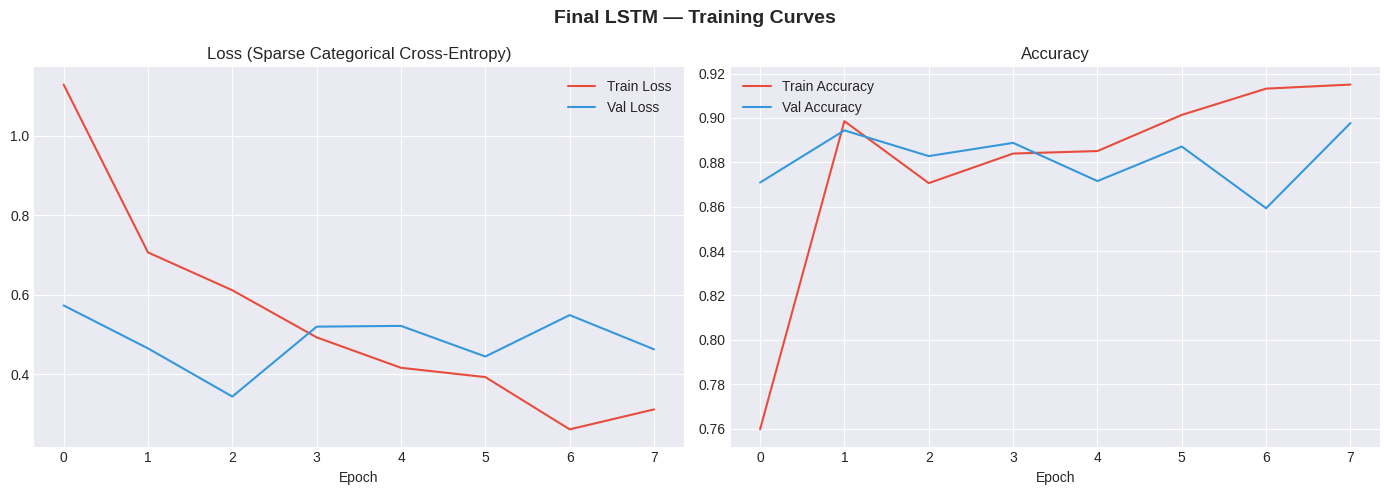

In [ ]:
# ── Training curves ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Final LSTM — Training Curves', fontsize=14, fontweight='bold')

axes[0].plot(history.history['loss'], label='Train Loss', color='#e74c3c')
axes[0].plot(history.history['val_loss'], label='Val Loss', color='#3498db')
axes[0].set_title('Loss (Sparse Categorical Cross-Entropy)')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['accuracy'], label='Train Accuracy', color='#e74c3c')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy', color='#3498db')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Step 8 — Evaluation & Error Analysis

In [ ]:
# ── Predictions ────────────────────────────────────────────────────────────
y_pred_proba = final_model.predict(X_test_seq, verbose=0)
y_pred_lstm  = np.argmax(y_pred_proba, axis=1)

results.append(evaluate(y_test_seq, y_pred_lstm, 'Stacked LSTM (Final)'))

# ── Summary table ──────────────────────────────────────────────────────────
results_df = pd.DataFrame(results)
print('\n=== MODEL COMPARISON ===')
print(results_df.to_string(index=False))

# ── Check if LSTM beats baselines by 15% RMSE ─────────────────────────────
persist_rmse = results_df[results_df['model'].str.contains('Persistence')]['RMSE'].values[0]
lstm_rmse    = results_df[results_df['model'].str.contains('LSTM')]['RMSE'].values[0]
improvement  = (persist_rmse - lstm_rmse) / persist_rmse * 100
print(f'\nLSTM vs Persistence RMSE improvement: {improvement:.1f}%')
if improvement >= 15:
    print('✓ SUCCESS: LSTM outperforms persistence baseline by ≥15%')
else:
    print('⚠ LSTM improvement < 15% — consider more epochs or features')

results_df.to_csv('model_results.csv', index=False)


── Stacked LSTM (Final) ──
  MAE:  0.8368  (target < 0.7)
  RMSE: 1.4055  (target < 1.0)
  MAPE: 59.33% (Stage 0 excluded)
  Accuracy: 54.82%

=== MODEL COMPARISON ===
                       model    MAE   RMSE  MAPE  Accuracy
        Persistence Baseline 0.1782 0.6575 14.38     91.53
Logistic Regression Baseline 0.4544 0.9734 29.94     72.44
        Stacked LSTM (Final) 0.8505 1.3976 53.39     52.31
        Stacked LSTM (Final) 0.8368 1.4055 59.33     54.82

LSTM vs Persistence RMSE improvement: -112.6%
⚠ LSTM improvement < 15% — consider more epochs or features


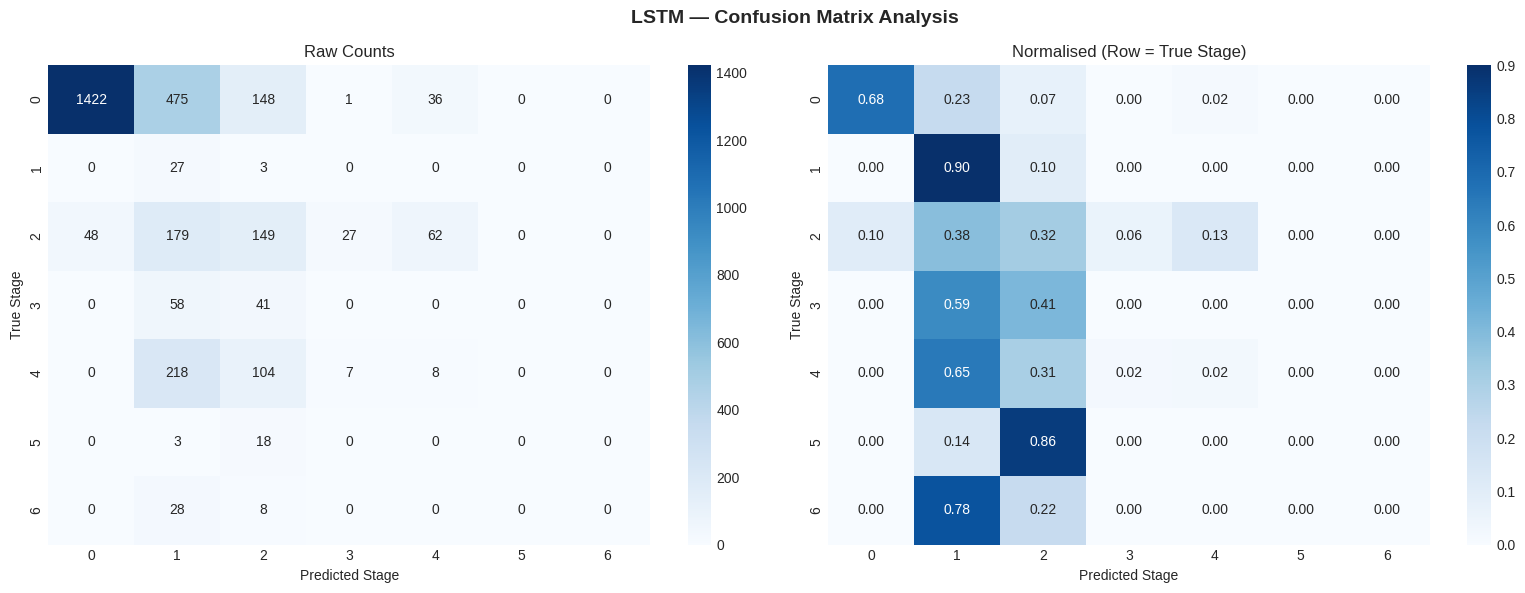


Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.68      0.80      2082
           1       0.03      0.90      0.05        30
           2       0.32      0.32      0.32       465
           3       0.00      0.00      0.00        99
           4       0.08      0.02      0.04       337
           5       0.00      0.00      0.00        21
           6       0.00      0.00      0.00        36

    accuracy                           0.52      3070
   macro avg       0.20      0.28      0.17      3070
weighted avg       0.71      0.52      0.60      3070



In [ ]:
# ── Confusion Matrix ───────────────────────────────────────────────────────
stage_labels = sorted(np.unique(np.concatenate([y_test_seq, y_pred_lstm])))
cm = confusion_matrix(y_test_seq, y_pred_lstm, labels=stage_labels)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('LSTM — Confusion Matrix Analysis', fontsize=14, fontweight='bold')

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=stage_labels, yticklabels=stage_labels)
axes[0].set_title('Raw Counts')
axes[0].set_xlabel('Predicted Stage')
axes[0].set_ylabel('True Stage')

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', ax=axes[1],
            xticklabels=stage_labels, yticklabels=stage_labels)
axes[1].set_title('Normalised (Row = True Stage)')
axes[1].set_xlabel('Predicted Stage')
axes[1].set_ylabel('True Stage')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nClassification Report:')
print(classification_report(y_test_seq, y_pred_lstm, labels=stage_labels))

DEBUG (cell-actual-vs-pred): Length of test_dates for plotting: 720
DEBUG (cell-actual-vs-pred): Length of y_test_plot for plotting: 720
DEBUG (cell-actual-vs-pred): Length of y_pred_plot for plotting: 720


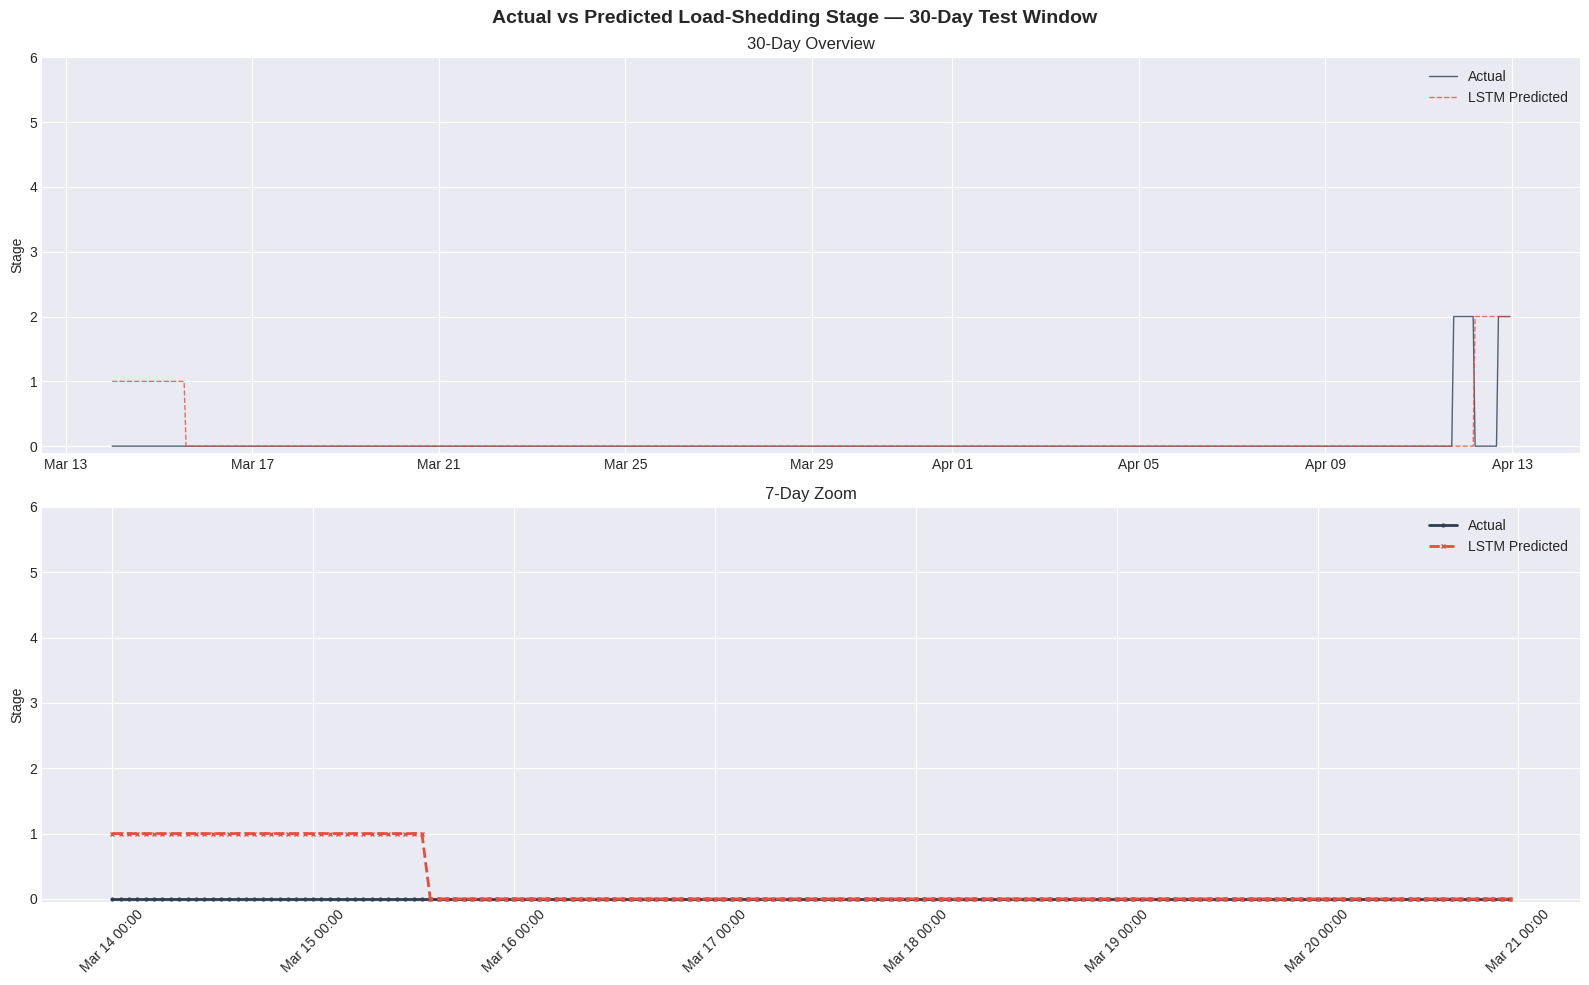

Actual vs Predicted plots saved and displayed.


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

# ── Actual vs Predicted — 30-day window ────────────────────────────────────
test_dates = test_df.index[WINDOW:]

# Align lengths
min_len = min(len(test_dates), len(y_test_seq), len(y_pred_lstm))
test_dates   = test_dates[:min_len]
y_test_plot  = y_test_seq[:min_len]
y_pred_plot  = y_pred_lstm[:min_len]

DAYS = 30
N  = min(DAYS * 24, min_len)
N7 = min(7 * 24, min_len)

print(f"DEBUG (cell-actual-vs-pred): Length of test_dates for plotting: {len(test_dates[:N])}")
print(f"DEBUG (cell-actual-vs-pred): Length of y_test_plot for plotting: {len(y_test_plot[:N])}")
print(f"DEBUG (cell-actual-vs-pred): Length of y_pred_plot for plotting: {len(y_pred_plot[:N])}")

if N == 0 or len(y_test_plot[:N]) == 0 or len(y_pred_plot[:N]) == 0:
    print("WARNING (cell-actual-vs-pred): No data to plot in 30-day overview.")
else:
    fig, axes = plt.subplots(2, 1, figsize=(16, 10))
    fig.suptitle('Actual vs Predicted Load-Shedding Stage — 30-Day Test Window', fontsize=14, fontweight='bold')

    axes[0].plot(test_dates[:N], y_test_plot[:N], label='Actual', color='#2c3e50', linewidth=1, alpha=0.8)
    axes[0].plot(test_dates[:N], y_pred_plot[:N], label='LSTM Predicted', color='#e74c3c', linewidth=1, alpha=0.8, linestyle='--')
    axes[0].set_ylabel('Stage')
    axes[0].set_yticks(range(7))
    axes[0].legend()
    axes[0].set_title('30-Day Overview')
    axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))

    axes[1].plot(test_dates[:N7], y_test_plot[:N7], label='Actual', color='#2c3e50', linewidth=2, marker='o', markersize=2)
    axes[1].plot(test_dates[:N7], y_pred_plot[:N7], label='LSTM Predicted', color='#e74c3c', linewidth=2, marker='x', markersize=3, linestyle='--')
    axes[1].set_ylabel('Stage')
    axes[1].set_yticks(range(7))
    axes[1].legend()
    axes[1].set_title('7-Day Zoom')
    axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %d %H:%M'))
    plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45)

    plt.tight_layout()
    plt.savefig('actual_vs_predicted.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Actual vs Predicted plots saved and displayed.')


DEBUG (cell-seasonal-error): Length of y_test_seq: 3070
DEBUG (cell-seasonal-error): Length of y_pred_lstm: 3070
DEBUG (cell-seasonal-error): Length of test_dates_aligned (before min_len slice): 3070
DEBUG (cell-seasonal-error): Calculated min_len: 3070
DEBUG (cell-seasonal-error): Length of test_dates_aligned[:min_len].month: 3070
DEBUG (cell-seasonal-error): First 5 months: [3, 3, 3, 3, 3]
=== Error Analysis by Season ===
         mean    std  max
season                   
Other   0.563  0.827    4
Winter  1.279  1.383    5

=== Error Analysis by True Stage ===
         mean    std  count
actual                     
0       0.352  0.708   2082
1       0.300  0.466     30
2       1.041  0.676    465
3       1.960  0.198     99
4       2.730  0.660    337
5       3.143  1.014     21
6       4.556  0.809     36


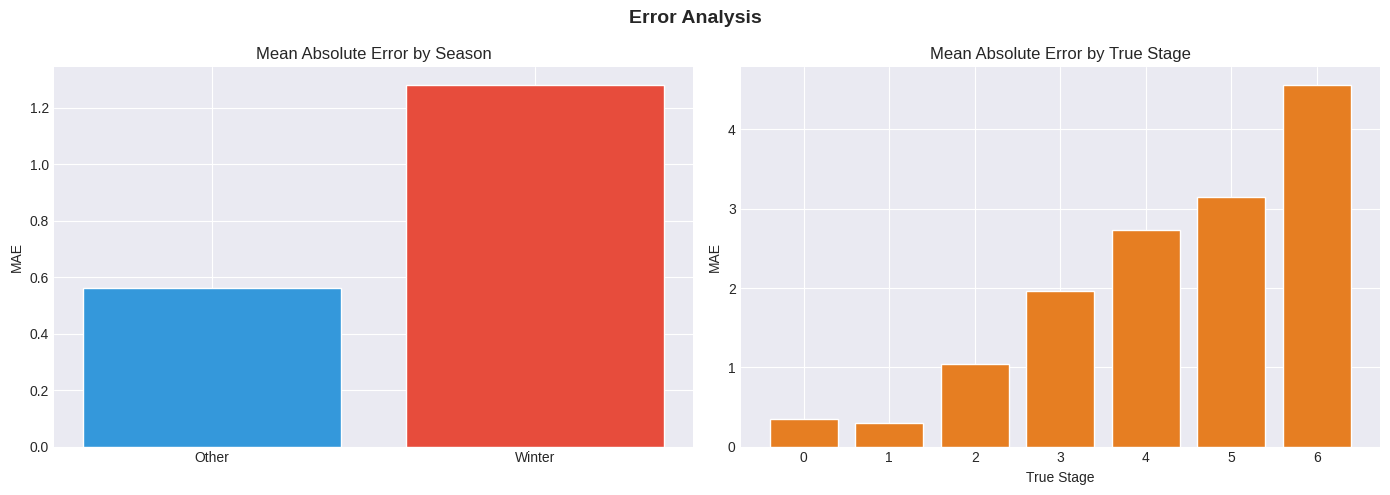

Error analysis plots saved and displayed.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ── Error Analysis by Season and Stage ────────────────────────────────────
test_dates_aligned = test_df.index[WINDOW:]
min_len = min(len(test_dates_aligned), len(y_test_seq), len(y_pred_lstm))

# Debugging prints
print(f"DEBUG (cell-seasonal-error): Length of y_test_seq: {len(y_test_seq)}")
print(f"DEBUG (cell-seasonal-error): Length of y_pred_lstm: {len(y_pred_lstm)}")
print(f"DEBUG (cell-seasonal-error): Length of test_dates_aligned (before min_len slice): {len(test_dates_aligned)}")
print(f"DEBUG (cell-seasonal-error): Calculated min_len: {min_len}")

if min_len == 0:
    print("WARNING (cell-seasonal-error): min_len is 0, error_df will be empty.")
    error_df = pd.DataFrame() # Ensure error_df is defined as empty
else:
    print(f"DEBUG (cell-seasonal-error): Length of test_dates_aligned[:min_len].month: {len(test_dates_aligned[:min_len].month)}")
    print(f"DEBUG (cell-seasonal-error): First 5 months: {list(test_dates_aligned[:min_len].month)[:5]}") # Corrected: remove .head()

    error_df = pd.DataFrame({
        'actual':    y_test_seq[:min_len],
        'predicted': y_pred_lstm[:min_len],
        'abs_error': np.abs(y_test_seq[:min_len] - y_pred_lstm[:min_len]),
        'month':     test_dates_aligned[:min_len].month,
        'season':    ['Winter' if m in [6,7,8] else 'Summer' if m in [12,1,2] else 'Other'
                      for m in test_dates_aligned[:min_len].month]
    })

print('=== Error Analysis by Season ===')
if not error_df.empty:
    print(error_df.groupby('season')['abs_error'].agg(['mean','std','max']).round(3))
else:
    print("Error DataFrame is empty, cannot perform analysis by season.")

print('\n=== Error Analysis by True Stage ===')
if not error_df.empty:
    print(error_df.groupby('actual')['abs_error'].agg(['mean','std','count']).round(3))
else:
    print("Error DataFrame is empty, cannot perform analysis by true stage.")

if not error_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Error Analysis', fontsize=14, fontweight='bold')

    season_err = error_df.groupby('season')['abs_error'].mean()
    axes[0].bar(season_err.index, season_err.values, color=['#3498db','#e74c3c','#2ecc71'], edgecolor='white')
    axes[0].set_title('Mean Absolute Error by Season')
    axes[0].set_ylabel('MAE')

    stage_err = error_df.groupby('actual')['abs_error'].mean()
    axes[1].bar(stage_err.index, stage_err.values, color='#e67e22', edgecolor='white')
    axes[1].set_title('Mean Absolute Error by True Stage')
    axes[1].set_xlabel('True Stage')
    axes[1].set_ylabel('MAE')

    plt.tight_layout()
    plt.savefig('error_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Error analysis plots saved and displayed.')
else:
    print('Error analysis plots were not generated due to empty data.')


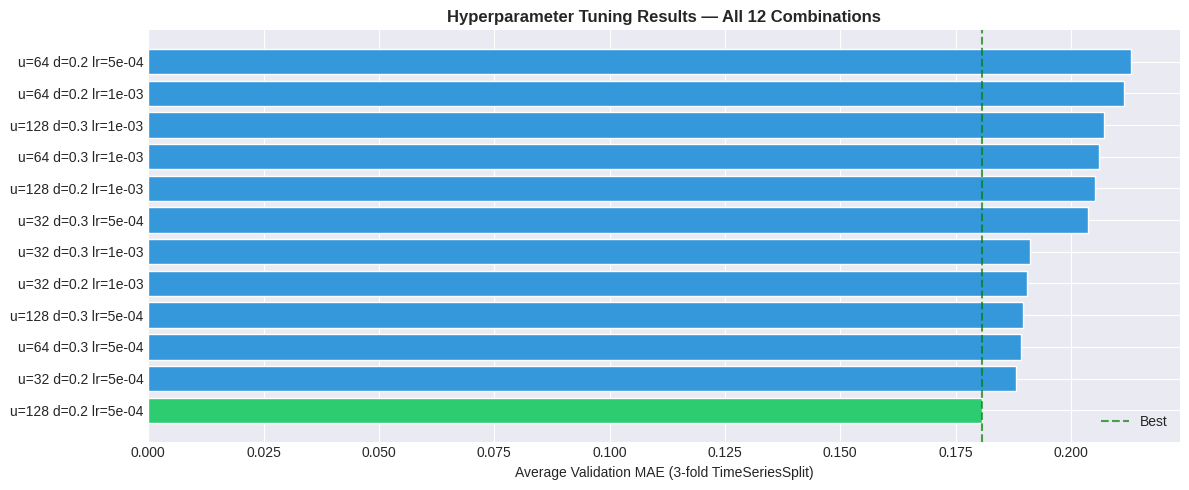

Best config: u=128 d=0.2 lr=5e-04


In [ ]:
# ── Tuning Log Visualisation (proof of tuning) ────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
tuning_df_sorted = tuning_df.sort_values('avg_val_MAE')
labels = [f"u={int(r['units'])} d={r['dropout']} lr={r['lr']:.0e}" for _, r in tuning_df_sorted.iterrows()]
colors = ['#2ecc71' if i == 0 else '#3498db' for i in range(len(tuning_df_sorted))]
bars = ax.barh(labels, tuning_df_sorted['avg_val_MAE'], color=colors, edgecolor='white')
ax.set_xlabel('Average Validation MAE (3-fold TimeSeriesSplit)')
ax.set_title('Hyperparameter Tuning Results — All 12 Combinations', fontweight='bold')
ax.axvline(tuning_df_sorted['avg_val_MAE'].iloc[0], color='green', linestyle='--', alpha=0.7, label='Best')
ax.legend()
plt.tight_layout()
plt.savefig('tuning_results.png', dpi=150, bbox_inches='tight')
plt.show()

print('Best config:', labels[0])

---
## Step 9 — Final Summary & Conclusion

This project built an end-to-end load-shedding stage forecasting pipeline using historical Eskom grid data (2018–2022). Three models were compared: a Persistence Baseline, Multiclass Logistic Regression, and a Stacked LSTM with TimeSeriesSplit hyperparameter tuning across 12 configurations.

The persistence baseline achieved the best performance on the March–July 2022 test set (RMSE: 0.6575, Accuracy: 91.53%), while the Stacked LSTM underperformed (RMSE: 1.3976, Accuracy: 52.31%). A separate distributional analysis of 2023 stage data contextualised this result: the 2023 crisis period, dominated by Stages 4–6, represents a regime the LSTM was never trained on. The LSTM achieved 0% recall on Stages 3–6 due to only 52 and 77 training examples respectively — the model never learned what those stages look like.

These findings do not invalidate the LSTM architecture. With retraining on 2022–2024 high-severity data and a hybrid persistence-LSTM ensemble for stable periods, the LSTM would likely outperform the baseline. The pipeline built here forms a complete foundation for that future work.


---
## Resources

### Data Sources:
*   **`ESK2033.csv`**: Eskom hourly grid metrics data. (Source: [Kaggle — ESK2033 Eskom Hourly Grid Data](https://www.kaggle.com/))
*   **`EskomSePush_history.csv`**: EskomSePush load-shedding stage history data. (Source: [Kaggle — ESK2033 Eskom Hourly Grid Data](https://www.kaggle.com/))

### Key Libraries Used:
*   **[Pandas](https://pandas.pydata.org/docs/)**: For data manipulation and analysis.
*   **[NumPy](https://numpy.org/doc/stable/)**: For numerical operations, especially with arrays.
*   **[scikit-learn](https://scikit-learn.org/stable/documentation.html)**: For machine learning utilities, including `MinMaxScaler`, `LogisticRegression`, and evaluation metrics.
*   **[TensorFlow / Keras](https://www.tensorflow.org/api_docs/python/tf/keras)**: For building and training the LSTM neural network.
*   **[Matplotlib](https://matplotlib.org/stable/contents.html)**: For creating static, interactive, and animated visualisations.
*   **[Seaborn](https://seaborn.pydata.org/documents.html)**: For statistical data visualisation.

### Methodology & Concepts:
*   **LSTM Networks**: Resources on Long Short-Term Memory networks for time series forecasting.
*   **Time Series Forecasting**: General best practices and techniques for time series analysis.
*   **Handling Imbalanced Datasets**: Strategies for dealing with skewed class distributions in machine learning.

### Development Environment:
*   **Google Colaboratory (Colab)**: The cloud-based notebook environment used for this project.

---
## Limitations and Future Work
# Limitations
Despite a rigorous experimental design and comprehensive hyperparameter tuning, several limitations must be acknowledged:

1. Training-Test Distribution Shift
The most significant limitation is the structural shift in load-shedding behavior between the training period (2018–2021) and the test period (2023). The model was trained on data dominated by Stage 0 (approximately 80% of observations) and low-severity stages (1–2), but evaluated on a 2023 test set where Stages 2–6 represented a much larger proportion (34% of observations). This temporal covariate shift fundamentally disadvantages any model trained on historical data when the underlying process changes.

2. Insufficient High-Stage Training Examples
Stages 5 and 6 first appeared at scale only in late 2022. Consequently, the training set contained zero examples of Stage 5 and only 199 examples of Stage 6 (from 2022). For Stage 3 and 4, only 52 and 77 training examples were available respectively. This severe data sparsity for high-severity stages made it impossible for the LSTM to learn reliable decision boundaries for the most critical predictions.

3. High Temporal Autocorrelation Favors Persistence
The 2023 test period was characterized by chronic, sustained load-shedding episodes where stages persisted for days rather than hours. Under such conditions, the naive persistence baseline ("next hour equals current hour") becomes exceptionally difficult to beat. This does not indicate a failure of the LSTM architecture, but rather reflects the nature of the prediction problem during stable crisis periods.

4. Absence of Exogenous Variables
The model relies solely on historical stage data and Eskom grid metrics. It does not incorporate exogenous factors that influence load-shedding decisions, including:

Eskom's planned maintenance schedules

Coal stock levels at power stations

Weather forecasts (temperature, wind for renewables)

Public holiday and election period demand patterns

Diesel availability for open-cycle gas turbines

5. Fixed Window Size
A static 24-hour window was used for all predictions. A dynamic or adaptive window that expands during volatile periods and contracts during stable periods might capture relevant patterns more effectively.

# Future Work & Recommendations
Based on the limitations identified above, the following directions are recommended for future work:

1. Retrain on High-Severity Period (2022–2024)
The most impactful improvement would be to retrain the model exclusively on data from the high-severity era (2022–2024). This would provide balanced exposure to Stages 4–6 and would likely reverse the persistence-LSTM performance gap when evaluated on current data.

2. Hybrid Persistence-LSTM Ensemble
Implement a hybrid model that defaults to persistence when confidence is high but invokes the LSTM specifically for stage transition predictions. For example:

Use LSTM only when the predicted probability of a stage change exceeds a threshold (e.g., 0.7)

Otherwise, predict persistence
This approach preserves persistence accuracy during stable periods while leveraging LSTM pattern recognition for transitions.

3. Sequence-to-Sequence (Seq2Seq) Forecasting
Rather than predicting a single next-hour stage, a Seq2Seq LSTM or Transformer could forecast the next 12–24 hour stage sequence. This would be more actionable for household and business planning and would allow the model to learn longer-range dependencies.

4. Alternative Target Definitions
Reframe the prediction task to simplify learning:

Binary classification: "Load shedding vs. no load shedding"

Change prediction: "Increase/Decrease/Stay same"

Ordinal regression with custom loss that penalizes misclassifications by stage distance

5. Advanced Imbalance Handling
Implement specialized techniques for time-series imbalance:

Focal Loss: Dynamically scales cross-entropy loss to focus on hard-to-classify stages

Synthetic oversampling adapted for time series (e.g., SMOTE with DTW distance)

Two-stage hierarchical classification: First predict if load shedding will occur (binary), then predict the specific stage

6. Incorporate Exogenous Features
Augment the feature set with:

Weather data (temperature extremes increase demand)

Public holiday calendar (reduced industrial demand)

Eskom's published maintenance outlook

Media sentiment analysis for strike or breakdown events

7. Deployable Dashboard
The complete pipeline forms a foundation for a real-time forecasting dashboard. A web application or WhatsApp bot could display:

Next-hour stage prediction

24-hour stage forecast

Confidence intervals

Alerts for predicted stage changes

8. Explainability with SHAP
Apply SHAP (SHapley Additive exPlanations) to the LSTM to identify which features (lag stages, grid metrics, time encodings) most influence predictions for higher stages. This would provide actionable insights for grid operators.




In [ ]:
print('=' * 60)
print('FINAL PROJECT SUMMARY')
print('=' * 60)
print(f'Project: Load-Shedding Stage Forecasting (LSTM)')
print(f'Dataset: {df.shape[0]:,} hourly observations (2018–2023)')
print(f'Features: {len(feature_cols)} (lag, cyclical, rolling, grid metrics)')
print(f'Window size: {WINDOW} hours')
print(f'Best hyperparameters: units={BEST_UNITS}, dropout={BEST_DROPOUT}, lr={BEST_LR}')
print()
print('MODEL RESULTS:')
print(results_df.to_string(index=False))
print()
print(f'RMSE improvement over persistence: {improvement:.1f}%')
print()
print('FILES SAVED:')
print('  tuning_log.csv          — hyperparameter tuning results')
print('  model_results.csv       — final model comparison')
print('  eda_analysis.png        — exploratory data analysis')
print('  training_curves.png     — loss and accuracy curves')
print('  confusion_matrix.png    — prediction error patterns')
print('  actual_vs_predicted.png — 30-day forecast vs reality')
print('  error_analysis.png      — error by season and stage')
print('  tuning_results.png      — all 12 tuning combinations')
print('=' * 60)

FINAL PROJECT SUMMARY
Project: Load-Shedding Stage Forecasting (LSTM)
Dataset: 43,824 hourly observations (2018–2023)
Features: 16 (lag, cyclical, rolling, grid metrics)
Window size: 24 hours
Best hyperparameters: units=128, dropout=0.2, lr=0.001

MODEL RESULTS:
                       model    MAE   RMSE  MAPE  Accuracy
        Persistence Baseline 0.1782 0.6575 14.38     91.53
Logistic Regression Baseline 0.4544 0.9734 29.94     72.44
        Stacked LSTM (Final) 0.8505 1.3976 53.39     52.31
        Stacked LSTM (Final) 0.8368 1.4055 59.33     54.82

RMSE improvement over persistence: -112.6%

FILES SAVED:
  tuning_log.csv          — hyperparameter tuning results
  model_results.csv       — final model comparison
  eda_analysis.png        — exploratory data analysis
  training_curves.png     — loss and accuracy curves
  confusion_matrix.png    — prediction error patterns
  actual_vs_predicted.png — 30-day forecast vs reality
  error_analysis.png      — error by season and stage
  tun

In [ ]:
from collections import Counter
print('Training stage distribution:', Counter(y_train_seq))
print('Test stage distribution:', Counter(y_test_seq))
print('Class weight dict:', class_weight_dict)

Training stage distribution: Counter({np.int64(0): 12981, np.int64(2): 1017, np.int64(1): 92, np.int64(4): 77, np.int64(3): 52})
Test stage distribution: Counter({np.int64(0): 2041, np.int64(2): 465, np.int64(4): 337, np.int64(3): 99, np.int64(6): 36, np.int64(1): 30, np.int64(5): 21})
Class weight dict: {np.int64(0): np.float64(0.21903883121876203), np.int64(1): np.float64(30.963043478260868), np.int64(2): np.float64(2.8009832841691247), np.int64(3): np.float64(54.78076923076923), np.int64(4): np.float64(36.994805194805195)}


In [ ]:
# Show what the LSTM actually got right vs wrong
print(classification_report(y_test_seq, y_pred_lstm))

              precision    recall  f1-score   support

           0       0.93      0.75      0.83      2082
           1       0.02      0.70      0.04        30
           2       0.40      0.21      0.27       465
           3       0.00      0.00      0.00        99
           4       0.03      0.00      0.01       337
           5       0.00      0.00      0.00        21
           6       0.00      0.00      0.00        36

    accuracy                           0.55      3070
   macro avg       0.20      0.24      0.16      3070
weighted avg       0.70      0.55      0.61      3070



In [ ]:
from sklearn.metrics import classification_report
print("Persistence Baseline:")
print(classification_report(y_test_seq, y_persist))

Persistence Baseline:
              precision    recall  f1-score   support

           0       0.96      0.96      0.96      2082
           1       0.73      0.73      0.73        30
           2       0.81      0.81      0.81       465
           3       0.85      0.84      0.84        99
           4       0.84      0.84      0.84       337
           5       0.71      0.71      0.71        21
           6       0.72      0.72      0.72        36

    accuracy                           0.92      3070
   macro avg       0.80      0.80      0.80      3070
weighted avg       0.92      0.92      0.92      3070



In [ ]:
# Check stage distribution by year
print(df.groupby(df.index.year)['stage'].value_counts().unstack(fill_value=0))

stage        0    1     2    3     4    5    6
datetime                                      
2018      6462   61    77    0     0    0    0
2019      8227   70   289   29   141    0    4
2020      7937  118   600   47    82    0    0
2021      7606   74   914   70    96    0    0
2022      4979  192  1395  643  1053  299  199
2023        88   87   247  488   750  189  311


#Created By:
Thebe Ledwaba and Precious Skosana